<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1789 | Val: 434 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 14, accumulation steps = 1 (effective batch size ≈ 14, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 0.9950 acc 0.593 | val loss 0.6325 acc 0.763 *


[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 0.8457 acc 0.661 | val loss 0.6896 acc 0.753


[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.7392 acc 0.714 | val loss 0.6012 acc 0.765 *


[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.6358 acc 0.759 | val loss 0.5618 acc 0.820 *


[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.6271 acc 0.745 | val loss 0.5487 acc 0.783 *


...

[DenseNet-121] Epoch  20/100 | LR: 2.74e-06 | train loss 0.1520 acc 0.934 | val loss 0.3761 acc 0.876


[DenseNet-121] Epoch  21/100 | LR: 2.74e-07 | train loss 0.1561 acc 0.928 | val loss 0.3737 acc 0.876


[DenseNet-121] Epoch  22/100 | LR: 2.74e-07 | train loss 0.1529 acc 0.932 | val loss 0.3737 acc 0.882


[DenseNet-121] Epoch  23/100 | LR: 2.74e-07 | train loss 0.1677 acc 0.930 | val loss 0.3755 acc 0.887


[DenseNet-121] Epoch  24/100 | LR: 2.74e-07 | train loss 0.1572 acc 0.930 | val loss 0.3921 acc 0.878

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 24.

[DenseNet-121] Restored best checkpoint (val loss = 0.3461)


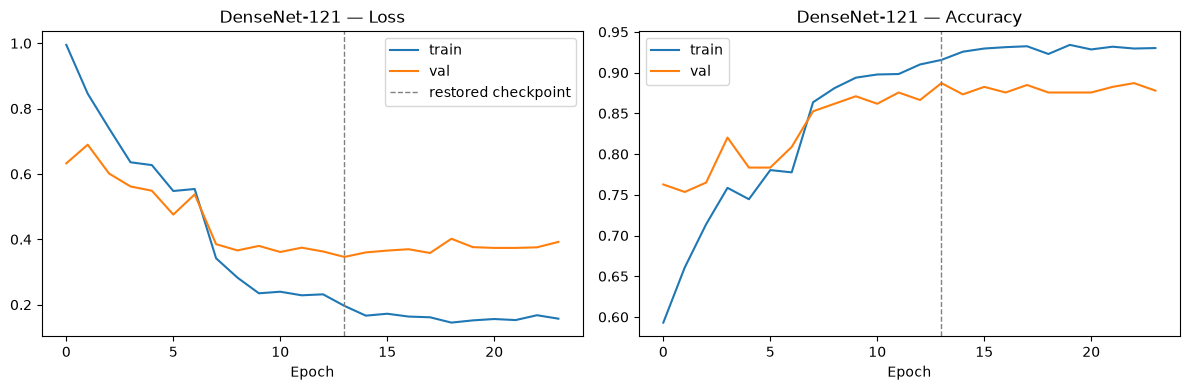

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.901


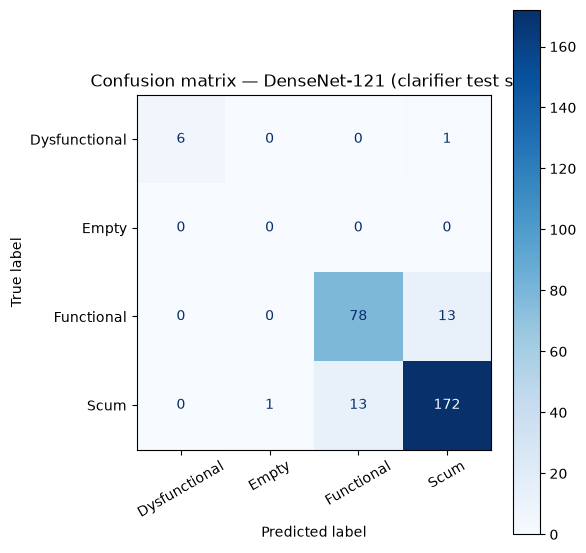

               precision    recall  f1-score   support

Dysfunctional      1.000     0.857     0.923         7
        Empty      0.000     0.000     0.000         0
   Functional      0.857     0.857     0.857        91
         Scum      0.925     0.925     0.925       186

     accuracy                          0.901       284
    macro avg      0.695     0.660     0.676       284
 weighted avg      0.905     0.901     0.903       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


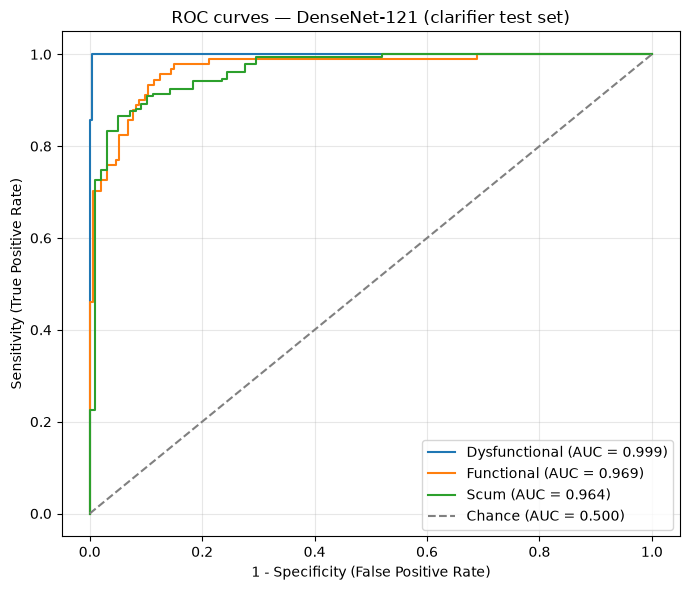

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.999
  Empty          : undefined (0 examples)
  Functional     : 0.969
  Scum           : 0.964

Mean AUC (over 3/4 classes with test examples): 0.977


(np.float64(0.9014084507042254),
 {'Dysfunctional': 0.999484270242393,
  'Empty': nan,
  'Functional': 0.9689688549792177,
  'Scum': 0.9640114110160193})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_Waterval.pkl


Saved model weights to ../models/clarifier_densenet121_cnn.pt
